RectBivariateSpline from Scipy

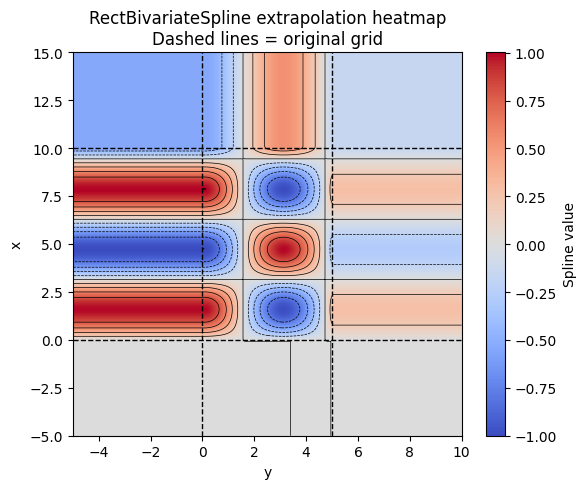

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline

# base grid for the spline
x = np.linspace(0, 10, 11)
y = np.linspace(0, 5, 6)
X, Y = np.meshgrid(x, y, indexing='ij')
Z = np.sin(X) * np.cos(Y)   # smooth function

# fit spline
spline = RectBivariateSpline(x, y, Z)

# bigger grid to view extrapolation
x_new = np.linspace(-5, 15, 200)     # extends beyond [0,10]
y_new = np.linspace(-5, 10, 200)     # extends beyond [0,5]
Z_new = spline(x_new, y_new)

# plot
plt.figure(figsize=(6,5))

extent = [y_new.min(), y_new.max(), x_new.min(), x_new.max()]
plt.imshow(Z_new, extent=extent, origin='lower', aspect='auto', cmap='coolwarm')
plt.colorbar(label='Spline value')

# contours for detail
plt.contour(y_new, x_new, Z_new, levels=10, colors='k', linewidths=0.5)

# draw original domain rectangle
plt.axvline(y.min(), color='k', linestyle='--', linewidth=1)
plt.axvline(y.max(), color='k', linestyle='--', linewidth=1)
plt.axhline(x.min(), color='k', linestyle='--', linewidth=1)
plt.axhline(x.max(), color='k', linestyle='--', linewidth=1)

plt.title("RectBivariateSpline extrapolation heatmap\nDashed lines = original grid")
plt.xlabel("y")
plt.ylabel("x")
plt.tight_layout()
plt.show()


Exercise: Find all roots of the function for using scipy or any other package you like.https://researchcomputing.readthedocs.io/en/stable/material/part11/notebook.html#Basic-matrix-operations 

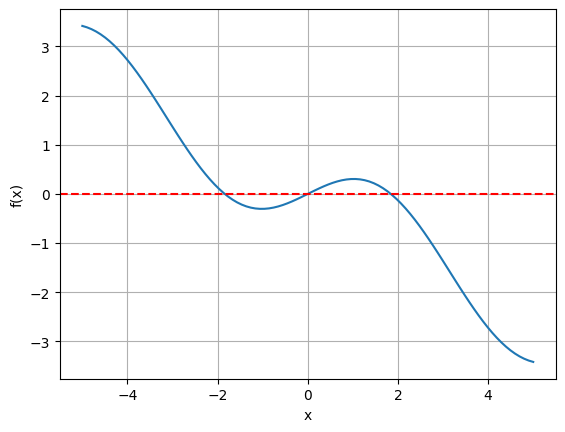

In [15]:
import matplotlib.pyplot as plt
# Define a single-variable function with y fixed
def f(x, a, b):
    return np.sin(x) * np.cos(a) - b*x


# Create a grid of x values
x = np.linspace(-5, 5, 100)

# Evaluate f for a=0.3, b=0.5
y = f(x, 0.3, 0.5)

# Plot
plt.figure()
plt.plot(x, y)
plt.grid(True)
plt.xlabel('x')
plt.ylabel('f(x)')

plt.axhline(y=0, color='r', linestyle='--')


In [16]:
import scipy

# Set the value of a, b to fix
a=0.3
b=0.5

# Use brentq to find the root of f with respect to x for the fixed a, b
# Provide an interval [a, b] where f(x, a, b) changes sign
x_root = scipy.optimize.brentq(f, 1, 2, args=(a,b))

print("Root found for x with a, b fixed at", a, b, ":", x_root)

Root found for x with a, b fixed at 0.3 0.5 : 1.8412298808552796


In [24]:
import numpy as np
from scipy.optimize import brentq

def find_multiple_roots(f, lo, hi, step=1.0, tol=1e-6):
    xs = np.arange(lo, hi + step, step)   # inclusive of hi
    roots = []

    for i in range(len(xs) - 1):
        x_i = xs[i]
        x_j = xs[i + 1]

        f_i = f(x_i)
        f_j = f(x_j)

        if abs(f_i) < tol:
            roots.append(x_i)
            continue

        if f_i * f_j < 0:
            root = brentq(f, x_i, x_j)
            # de-duplicate close roots
            if not roots or all(abs(root - r) > 1e-6 for r in roots):
                roots.append(root)

    # right-endpoint check
    if abs(f(xs[-1])) < tol:
        roots.append(xs[-1])

    return roots


In [25]:
a = 0.3
b = 0.5

def f(x): 
    return np.sin(x) * np.cos(a) - b*x

roots = find_multiple_roots(f, -4, 4, step=1.0)
print("Roots for a,b =", a, b, ":", roots)


Roots for a,b = 0.3 0.5 : [-1.8412298808552796, np.float64(0.0), 1.8412298808552796]


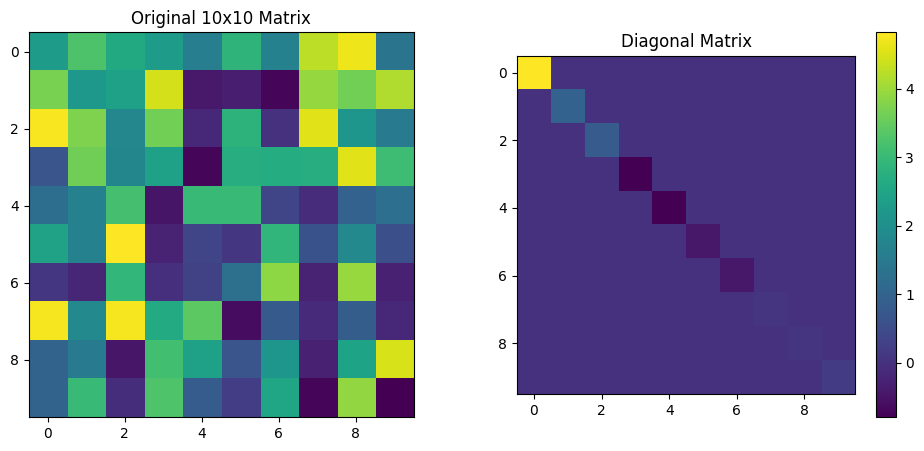

0.012191309322200517
Trace of original matrix: 4.457529730942303
Trace of (real) diagonal matrix: 4.457529730942311
Trace of (imaginary) diagonal matrix: 0.0


In [38]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

# Create a random 10x10 matrix for demonstration
np.random.seed(0)
matrix = np.random.rand(10, 10)

# Calculate the inverse, determinant, and eigenvalues/eigenvectors
matrix_inv = la.inv(matrix)
det = la.det(matrix)
eigvals, eigvecs = la.eig(matrix)

# Diagonalized matrix: D = V^-1 * A * V (where V is the eigenvector matrix)
# This reconstructs the diagonal form using the eigenvalues
diagonal_matrix = np.diag(eigvals.real)  # Only real part for visualization
imaginary_diagonal_matrix = np.diag(eigvals.imag)  # imaginary part
# Plotting the original and diagonalized matrices
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Show original matrix
axs[0].imshow(matrix, cmap="viridis")
axs[0].set_title("Original 10x10 Matrix")

# Show diagonalized matrix
axs[1].imshow(diagonal_matrix, cmap="viridis")
axs[1].set_title("Diagonalized Matrix (Eigenvalues on Diagonal)")

# Add subplot for eigenvector matrix
axs[1].set_title("Diagonal Matrix")
plt.colorbar(axs[1].imshow(diagonal_matrix, cmap="viridis"), ax=axs[1])

plt.show()

# Output determinant for reference
print(det)

# Calculate and print traces
print(f"Trace of original matrix: {np.trace(matrix)}")
print(f"Trace of (real) diagonal matrix: {np.trace(diagonal_matrix)}")
print(f"Trace of (imaginary) diagonal matrix: {np.trace(imaginary_diagonal_matrix)}")

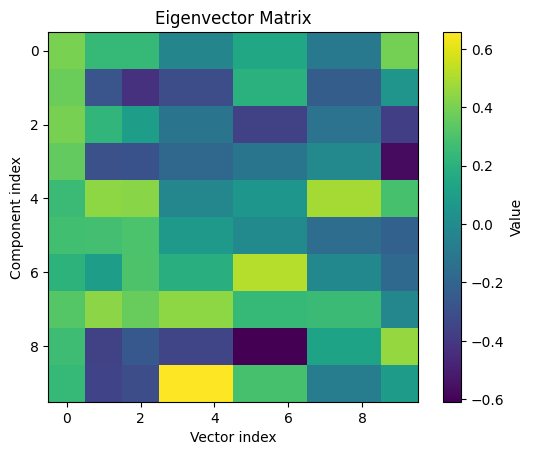

Are eigenvectors orthonormal? False


In [30]:
import matplotlib.pyplot as plt

# Suppose eigvecs is your matrix of eigenvectors
plt.imshow(eigvecs.real, cmap="viridis")  # show the real part
plt.colorbar(label="Value")
plt.title("Eigenvector Matrix")
plt.xlabel("Vector index")
plt.ylabel("Component index")
plt.show()
# Suppose eigvecs is your matrix of eigenvectors
check = np.allclose(eigvecs.conj().T @ eigvecs, np.eye(eigvecs.shape[0]))
print("Are eigenvectors orthonormal?", check)

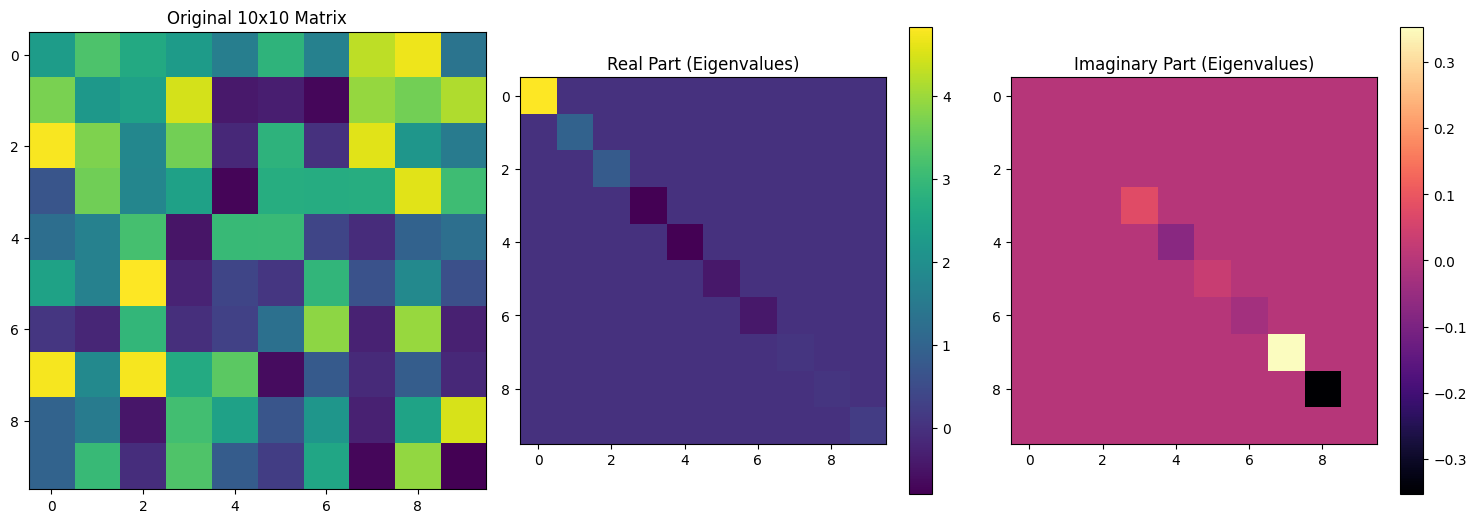

Trace of real diagonal matrix: 4.457529730942311
Trace of imaginary diagonal matrix: 0.0


In [37]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

# Create a random 10x10 matrix
np.random.seed(0)
matrix = np.random.rand(10, 10)

# Compute eigenvalues and eigenvectors
eigvals, eigvecs = la.eig(matrix)

# Separate real and imaginary parts of eigenvalues
real_diag = np.diag(eigvals.real)
imag_diag = np.diag(eigvals.imag)

# Plot both diagonal matrices
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Original matrix
axs[0].imshow(matrix, cmap="viridis")
axs[0].set_title("Original 10x10 Matrix")

# Real diagonal matrix
im1 = axs[1].imshow(real_diag, cmap="viridis")
axs[1].set_title("Real Part (Eigenvalues)")
plt.colorbar(im1, ax=axs[1])

# Imaginary diagonal matrix
im2 = axs[2].imshow(imag_diag, cmap="magma")
axs[2].set_title("Imaginary Part (Eigenvalues)")
plt.colorbar(im2, ax=axs[2])

plt.tight_layout()
plt.show()

# Print trace values for clarity
print(f"Trace of real diagonal matrix: {np.trace(real_diag)}")
print(f"Trace of imaginary diagonal matrix: {np.trace(imag_diag)}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider, Checkbox

# Function to generate a sawtooth signal
def generate_sawtooth_pattern(length=200, period=50):
    return np.tile(np.linspace(-1, 1, period), length // period)

# Function to create a Gaussian kernel
def gaussian_kernel(size=21, sigma=3.0):
    """
    Generate a Gaussian kernel.
    - Adjust the `size` parameter to control the width of the kernel.
    - Adjust the `sigma` parameter to control the amplitude (spread) of the kernel.
    """
    kernel = np.linspace(-(size // 2), size // 2, size)
    kernel = np.exp(-kernel**2 / (2 * sigma**2))
    kernel = kernel / np.sum(kernel)  # Normalize
    return kernel

# Function to perform 1D convolution (valid mode)
def convolve_1d(input_array, kernel):
    return np.convolve(input_array, kernel, mode='valid')

# Function to visualize the convolution process
def plot_convolution(step, input_array, kernel, result, save_as_svg):
    kernel_size = len(kernel)
    input_size = len(input_array)

    fig, axs = plt.subplots(3, 1, figsize=(9, 7))

    # Plot the input signal (Sawtooth)
    axs[0].plot(range(input_size), input_array, ls='-',lw=0.5,marker='o',markersize=0.3)
    axs[0].set_title('Input Array (Sawtooth Signal)')
    axs[0].set_xlim(0, input_size - 1)

    # Plot the kernel centered at the current step
    axs[1].stem(range(step, step + kernel_size), kernel, basefmt=" ", linefmt='None', markerfmt='C1o')
    axs[1].set_title(f'Gaussian Kernel')
    axs[1].set_xlim(0, input_size - 1)

    # Plot the result up to the current step
    axs[2].plot(range(len(result)), result, 'C2-')
    axs[2].set_title('Result of Convolution')
    axs[2].set_xlim(0, input_size - kernel_size)


    plt.tight_layout()


    # Save the plot as an SVG if requested
    if save_as_svg:
        plt.savefig('1dconv_sawtooth_plot.svg', format='svg')
        print("Plot saved as '1dconv_sawtooth_plot.svg'")


    plt.show()

# Interactive function
def interactive_convolution(step, size, sigma, save_as_svg=False):
    input_array = generate_sawtooth_pattern(length=200, period=50)  # More points, sawtooth pattern
    kernel = gaussian_kernel(size=size, sigma=sigma)  # Adjust width and amplitude here
    result = convolve_1d(input_array, kernel)
    plot_convolution(step, input_array, kernel, result[:step+1],save_as_svg)

# Create interactive sliders for convolution steps, kernel size (width), and kernel sigma (amplitude)
input_array = generate_sawtooth_pattern(length=200, period=50)

interact(
    interactive_convolution,
    step=IntSlider(min=0, max=len(convolve_1d(input_array, gaussian_kernel(21, 3.0))) - 1, step=1, value=0),
    size=IntSlider(min=3, max=51, step=2, value=21, description='Kernel Size'),
    sigma=FloatSlider(min=0.1, max=10.0, step=0.1, value=3.0, description='Sigma'),
    save_as_svg=Checkbox(value=False, description='Save as SVG')
)

# Splines Practise

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from patsy import dmatrix, build_design_matrices

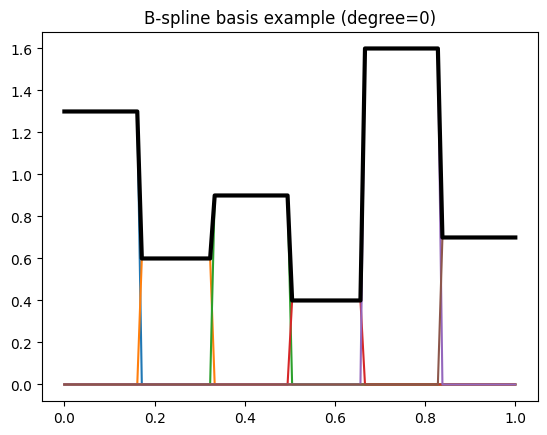

In [2]:
# Example predictor
x = np.linspace(0, 1, 100)
plt.title("B-spline basis example (degree=0)")

# 0-degree (piecewise constant) B-spline
y = dmatrix("bs(x, df=6, degree=0, include_intercept=True) - 1", 
                         {"x": x})
b = np.array([1.3,0.6,0.9,0.4,1.6,0.7])
# Plot basis functions
plt.plot(x, y*b);
plt.plot(x, np.dot(y,b),color='k',linewidth=3);

The graph above is called a piecewise (step) linear function. It has 0 degrees and at each step, it is a constant function. For example, when x is between 0 and 0.2, y is 1.3. Spline doesn't tell us much.

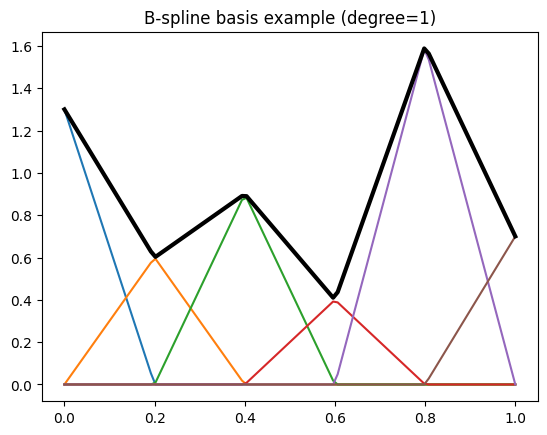

In [3]:
plt.title("B-spline basis example (degree=1)")
x = np.linspace(0., 1., 100)

y = dmatrix("bs(x, df=6, degree=1, include_intercept=True) - 1",
            {"x": x})

b = np.array([1.3, 0.6, 0.9, 0.4, 1.6, 0.7])

plt.plot(x, y * b)
plt.plot(x, np.dot(y, b), color='k', linewidth=3)

Better but not much going on here.

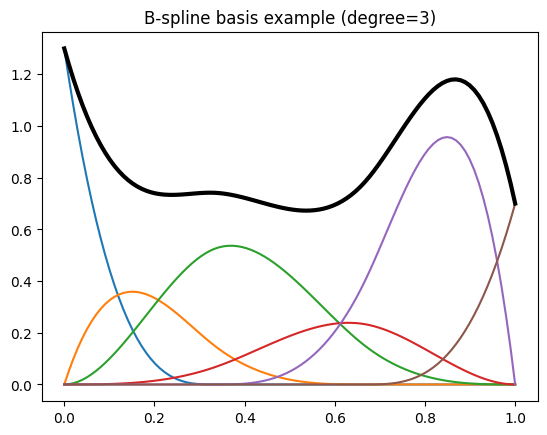

In [ ]:
plt.title("B-spline basis example (degree=3)");
x = np.linspace(0., 1., 100)
y = dmatrix("bs(x, df=6, degree=3, include_intercept=True) - 1", {"x": x})
b = np.array([1.3, 0.6, 0.9, 0.4, 1.6, 0.7])
plt.plot(x, y*b)
plt.plot(x, np.dot(y, b), color='k', linewidth=3);

In [6]:
dmatrix("bs(x, df=6, degree=3, include_intercept=True) - 1", {"x": x}, return_type = 'dataframe')

,"bs(x, df=6, degree=3, include_intercept=True)[0]","bs(x, df=6, degree=3, include_intercept=True)[1]","bs(x, df=6, degree=3, include_intercept=True)[2]","bs(x, df=6, degree=3, include_intercept=True)[3]","bs(x, df=6, degree=3, include_intercept=True)[4]","bs(x, df=6, degree=3, include_intercept=True)[5]"
0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.911818,0.086826,0.001352,0.000005,0.000000,0.000000
2,0.828978,0.165679,0.005306,0.000037,0.000000,0.000000
3,0.751315,0.236852,0.011708,0.000125,0.000000,0.000000
4,0.678660,0.300637,0.020406,0.000297,0.000000,0.000000
...,...,...,...,...,...,...
95,0.000000,0.000000,0.000297,0.020406,0.300637,0.678660
96,0.000000,0.000000,0.000125,0.011708,0.236852,0.751315
97,0.000000,0.000000,0.000037,0.005306,0.165679,0.828978
98,0.000000,0.000000,0.000005,0.001352,0.086826,0.911818


From the above table:

Each function from the graph (the colour is a function) is represented as columns. For example, column [0] is blue, column [1] is orange.
You combine them all into one function which is the thick black line.

To interpret the dataframe:

Take a row = one value of x
Calculate the value of this x for that spline function seperated in each column
Learn the slope function for each spline β₁ ... - this is like a weighted sum 
f(x) = β₁ * spline₁(x)
     + β₂ * spline₂(x)
     + β₃ * spline₃(x)
     + β₄ * spline₄(x)
     + β₅ * spline₅(x)
     + β₆ * spline₆(x)


From the lecture notes:

1. We start off with the outcome variable we aim to model. For example, we want to predict the used car price using the car's mileage.
2. We plot the relationship on a scatter graph between mileage and price. It looks like this:

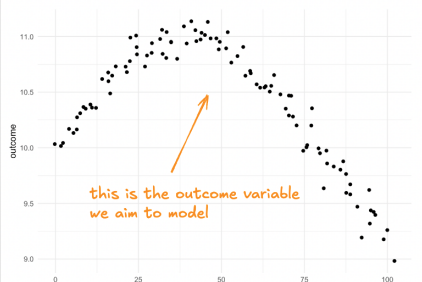

3. This is a non-linear, smooth graph but not a simple curve. This is when we use splines.
4. degrees of freedom (df) in the function creates 6 columns, where the functions are active over their respective part of the domain. 
5. The spline function is calculated at each point in the dataset and the data is fitted.

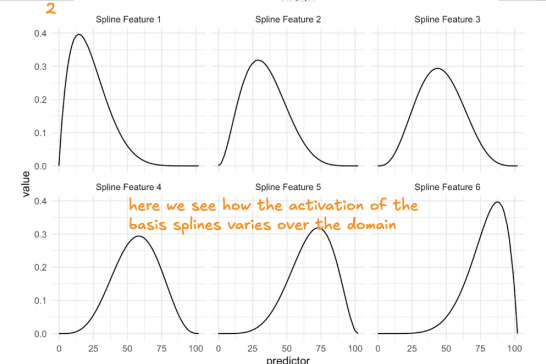

Definition: Knots = the x-values where two polynomial points meet. It's like a handover point to say, spline 1 is done now for the next part of the domain, use spline 2.
0 ---- 30 ---- 60 ---- 90 ---- 120
      ↑     ↑      ↑
    knot  knot   knot


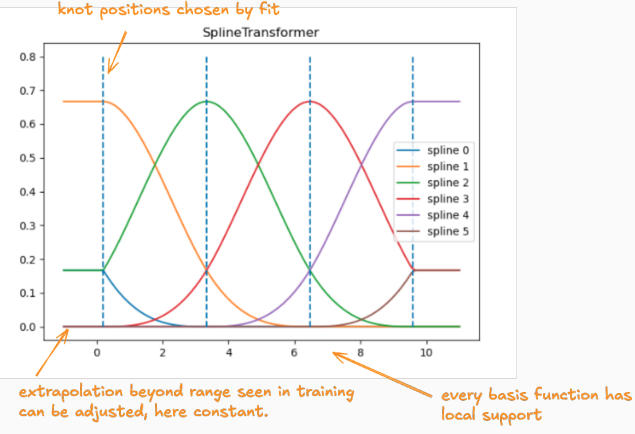

During extrapolation (outside the boundary defined), the spline functions return constants.

# Data Visualisation Practise

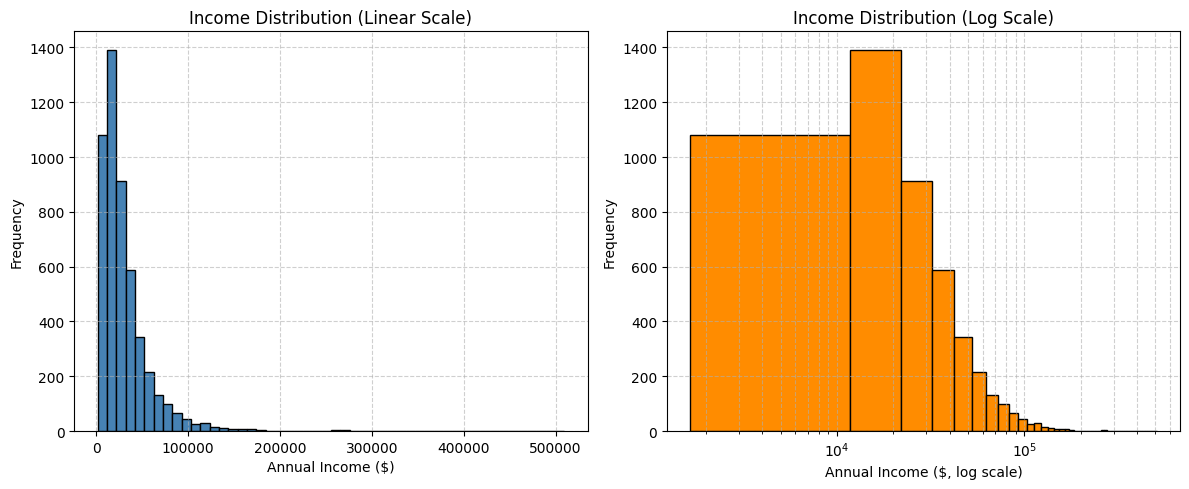

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate household income data (very skewed)
np.random.seed(42)
income = np.random.lognormal(mean=10, sigma=0.8, size=5000)  # lognormal distribution

# Create two subplots: linear vs log scale
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Linear scale histogram
ax1.hist(income, bins=50, color="steelblue", edgecolor="black")
ax1.set_title("Income Distribution (Linear Scale)")
ax1.set_xlabel("Annual Income ($)")
ax1.set_ylabel("Frequency")
ax1.grid(True, linestyle="--", alpha=0.6)

# Log scale histogram
ax2.hist(income, bins=50, color="darkorange", edgecolor="black")
ax2.set_xscale("log")  # key line
ax2.set_title("Income Distribution (Log Scale)")
ax2.set_xlabel("Annual Income ($, log scale)")
ax2.set_ylabel("Frequency")
ax2.grid(True, which="both", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


In [5]:
import numpy as np
import pandas as pd

np.random.seed(42)

continents = ["Africa", "Americas", "Asia", "Europe", "Oceania"]
years = [1970, 2010]

data = []

for cont in continents:
    for year in years:
        # Make 1970 poorer than 2010
        base = {
            "Africa": 1.5 if year == 1970 else 3,
            "Americas": 5 if year == 1970 else 10,
            "Asia": 3 if year == 1970 else 8,
            "Europe": 12 if year == 1970 else 20,
            "Oceania": 10 if year == 1970 else 15
        }[cont]
        
        # Create values with some variation
        incomes = np.random.lognormal(mean=np.log(base), sigma=0.35, size=40)

        for value in incomes:
            data.append([cont, year, value])

df = pd.DataFrame(data, columns=["continent", "year", "income"])
df.head()


,continent,year,income
0,Africa,1970,1.784816
1,Africa,1970,1.429140
2,Africa,1970,1.881663
3,Africa,1970,2.556210
4,Africa,1970,1.381972


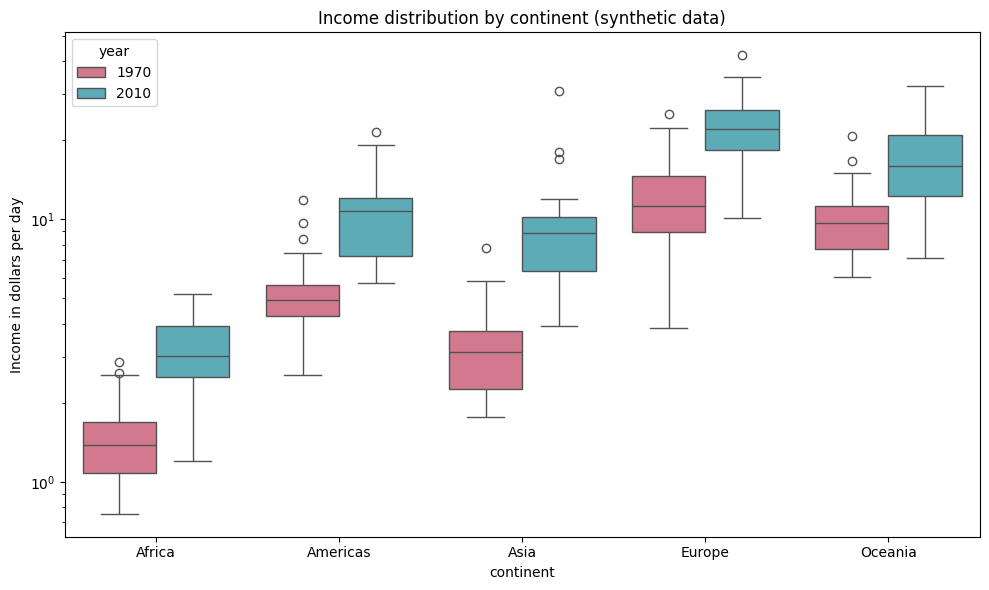

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="continent",
    y="income",
    hue="year",
    palette=["#E16A86", "#4DB6C6"]
)

plt.yscale("log")   # the original uses log-scale
plt.ylabel("Income in dollars per day")
plt.xlabel("continent")
plt.title("Income distribution by continent (synthetic data)")
plt.legend(title="year")
plt.tight_layout()
plt.show()


Example of Class Polymorphism

In [2]:
from src.mean import MeanModel
from src.max import MaxModel

X = [1,2,3]
y = [10,20,30]

models = [MeanModel(), MaxModel()]

for model in models:
    X_trans = model.transform(X)
    model.fit(X_trans, y)
    preds = model.predict(X_trans)
    print(model.__class__.__name__, preds)


MeanModel [20.0, 20.0, 20.0]
MaxModel [30, 30, 30]


Example of Numpy ufuncs

In [ ]:
import time
import numpy as np

arr = np.array([1,2,3])
start = time.perf_counter()
result = np.sqrt(arr)
end = time.perf_counter()

print("Time:", end - start, "seconds")

result = []
start = time.perf_counter()
for x in arr:
    result.append(x**2)
end = time.perf_counter()

print("Time:", end - start, "seconds")

Time: 0.00011799996718764305 seconds
Time: 5.004194099456072e-05 seconds


# Finding the right distribution of our dataset (D100 Statistical Modelling)

In [16]:
import pandas as pd


# Setting up the dataset, number of claims and exposure are a combination of our target variable, looking at the amount of claims per policy per year
df = pd.DataFrame({
    "Policy_ID": list(range(1, 51)),
    "Exposure": [
        1.0,1.0,1.0,0.8,1.0,0.9,1.0,1.0,0.7,1.0,
        1.0,1.0,0.6,1.0,1.0,1.0,0.9,1.0,1.0,1.0,
        1.0,1.0,0.8,1.0,1.0,1.0,0.9,1.0,1.0,1.0,
        1.0,1.0,0.7,1.0,1.0,1.0,0.95,0.85,1.0,1.0,
        1.0,1.0,0.9,1.0,1.0,1.0,0.8,1.0,1.0,1.0
    ],
    "ClaimNB": [
        0,0,1,0,0,0,2,0,0,1,
        0,0,0,0,1,0,0,0,0,0,
        1,0,0,0,0,0,0,1,0,0,
        0,0,2,0,0,0,0,0,1,0,
        0,0,0,0,0,1,0,0,0,0
    ]
})

print(df)


    Policy_ID  Exposure  ClaimNB
0           1      1.00        0
1           2      1.00        0
2           3      1.00        1
3           4      0.80        0
4           5      1.00        0
5           6      0.90        0
6           7      1.00        2
7           8      1.00        0
8           9      0.70        0
9          10      1.00        1
10         11      1.00        0
11         12      1.00        0
12         13      0.60        0
13         14      1.00        0
14         15      1.00        1
15         16      1.00        0
16         17      0.90        0
17         18      1.00        0
18         19      1.00        0
19         20      1.00        0
20         21      1.00        1
21         22      1.00        0
22         23      0.80        0
23         24      1.00        0
24         25      1.00        0
25         26      1.00        0
26         27      0.90        0
27         28      1.00        1
28         29      1.00        0
29        

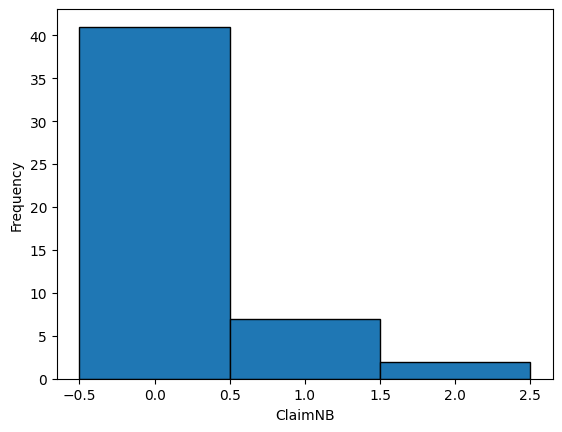

In [17]:
import matplotlib.pyplot as plt

plt.hist(df["ClaimNB"], bins=range(df["ClaimNB"].max()+2), align="left", edgecolor="black")
plt.xlabel("ClaimNB")
plt.ylabel("Frequency")
plt.show()


In [18]:
y = df["ClaimNB"]
print("Mean:", y.mean())
print("Variance:", y.var())


Mean: 0.22
Variance: 0.25673469387755105
